In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


informe sua ação: googl


/tmp/ipython-input-3588418702.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_acao = yf.download(acao, start=data_inicio, end=data_fim)
[*********************100%***********************]  1 of 1 completed


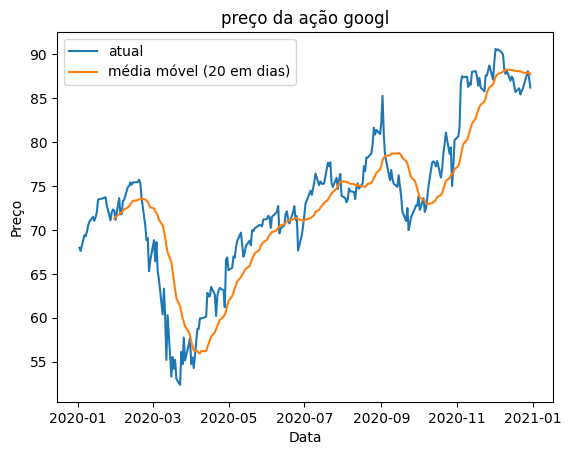

In [ ]:
import matplotlib.pyplot as plt
import yfinance as yf # pyright: ignore[reportMissingImports]
# baixar os dados do yf
def baixar_dados(acao, data_inicio, data_fim):
  dados_acao = yf.download(acao, start=data_inicio, end=data_fim)
  # média movel
  return dados_acao
def modelo_media_movel(dados, tamanho_janela):
  dados['Média Móvel'] = dados['Close'].rolling(window=tamanho_janela).mean()
  return dados
acao = input('informe sua ação: ')
data_inicio = '2020-01-01'
data_fim = '2020-12-31'
tamanho_janela = 20
dados = baixar_dados(acao, data_inicio, data_fim)
dados = modelo_media_movel(dados, tamanho_janela)
plt.plot(dados['Close'], label = 'atual')
plt.plot(dados['Média Móvel'], label = f'média móvel ({tamanho_janela} em dias)')
plt.title(f'preço da ação {acao}')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.show()

Informe a ação: msft


/tmp/ipython-input-2234733587.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_acao = yf.download(acao, start=data_inicio, end=data_fim)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0409


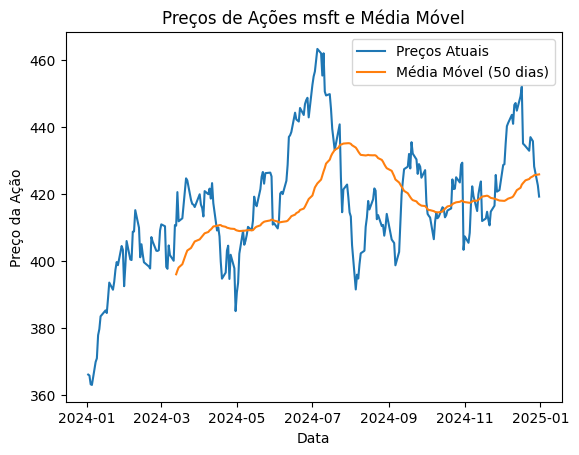

In [ ]:
import yfinance as yf  # type: ignore
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, LSTM # type: ignore


def baixar_dados(acao, data_inicio, data_fim):
    dados_acao = yf.download(acao, start=data_inicio, end=data_fim)
    return dados_acao

def modelo_media_movel(dados, tamanho_janela):
    dados['Média Móvel'] = dados['Close'].rolling(window=tamanho_janela).mean()
    return dados


acao = input('Informe a ação: ')
data_inicio = '2024-01-01'
data_fim = '2025-01-01'
tamanho_janela = 50

dados = baixar_dados(acao, data_inicio, data_fim)

# Verificar se os dados foram baixados com sucesso
if dados.empty:
    print(f"Erro: Não foi possível baixar dados para a ação '{acao}'.")
    print("Verifique se o ticker está correto. Exemplos: GOOGL, AAPL, MSFT, TSLA")
    raise SystemExit("Execução interrompida devido a erro no download dos dados.")

dados = modelo_media_movel(dados, tamanho_janela)

# Pré-processamento de Dados
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dados['Close'].values.reshape(-1, 1))

training_data_len = int(np.ceil(len(scaled_data) * .95))

train_data = scaled_data[0:int(training_data_len), :]

# Divisão dos Dados
x_train, y_train = [], []
for i in range(tamanho_janela, len(train_data)):
    x_train.append(train_data[i-tamanho_janela:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Construção do Modelo
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Treinamento do Modelo
model.fit(x_train, y_train, batch_size=1, epochs=1)

# Plotar resultados
plt.plot(dados['Close'], label='Preços Atuais')
plt.plot(dados['Média Móvel'], label=f'Média Móvel ({tamanho_janela} dias)')
plt.title(f'Preços de Ações {acao} e Média Móvel')
plt.xlabel('Data')
plt.ylabel('Preço da Ação')
plt.legend()
plt.show()